In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


Plot the distribution of price from products.csv, choosing a chart type suited to a continuous numeric variable

In [3]:
sales = pd.read_csv("../../../Data/sales.csv")
products = pd.read_csv("../../../Data/products.csv")
stores = pd.read_csv("../../../Data/stores.csv")
category = pd.read_csv("../../../Data/category.csv")
warranty = pd.read_csv("../../../Data/warranty.csv")

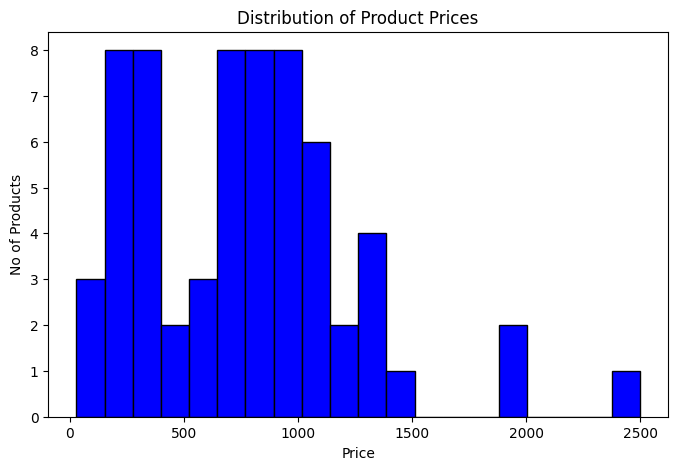

In [10]:
plt.figure(figsize=(8,5))
plt.hist(products['price'] ,bins = 20 , color = 'blue', edgecolor = 'black')

plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('No of Products')
grid = True 
plt.show()

Join products.csv with category.csv and plot the count of products per category_name, choosing a chart suited to categorical data.

In [5]:
product_category = products.merge(category, on='category_id', how='left')

In [6]:
category_count = (
    product_category
    .groupby("category_name")
    .size()
)

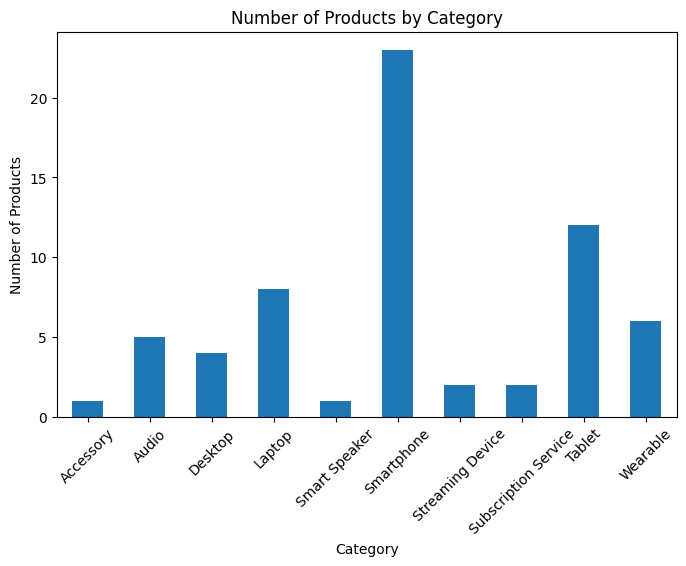

In [21]:
plt.figure(figsize=(8, 5))

category_count.plot(kind="bar")

plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.xticks(rotation=45)
plt.show()

Join sales.csv, products.csv, and category.csv, then visualize total units sold per category_name using a sorted, gridded bar chart

In [26]:
sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products_category = sales_products.merge(
    category,
    on="category_id",
    how="left"
)

In [27]:
category_quantity = (
    sales_products_category
    .groupby("category_name")["quantity"]
    .sum()
)

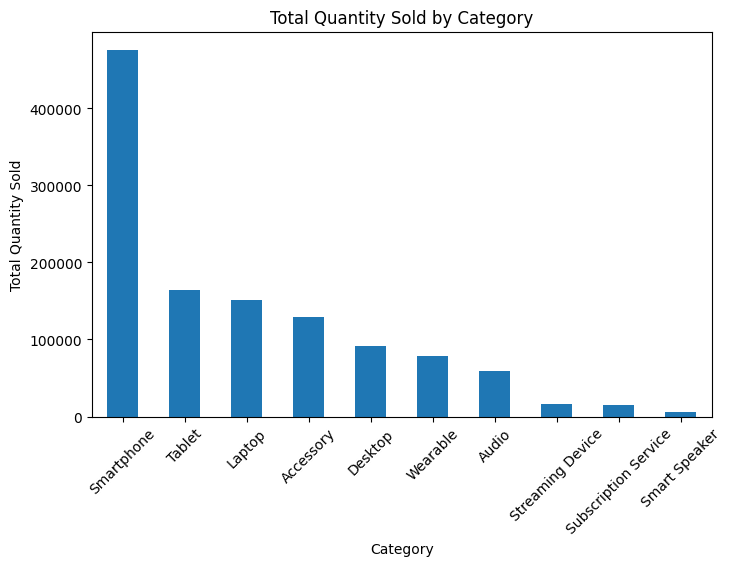

In [31]:
category_quantity = category_quantity.sort_values(ascending=False)


plt.figure(figsize=(8, 5))

category_quantity.plot(kind="bar")

plt.title("Total Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)

plt.show()

Visualize the number of Apple stores per country from stores.csv, using a defined figsize, rotated axis labels, and a descriptive title.

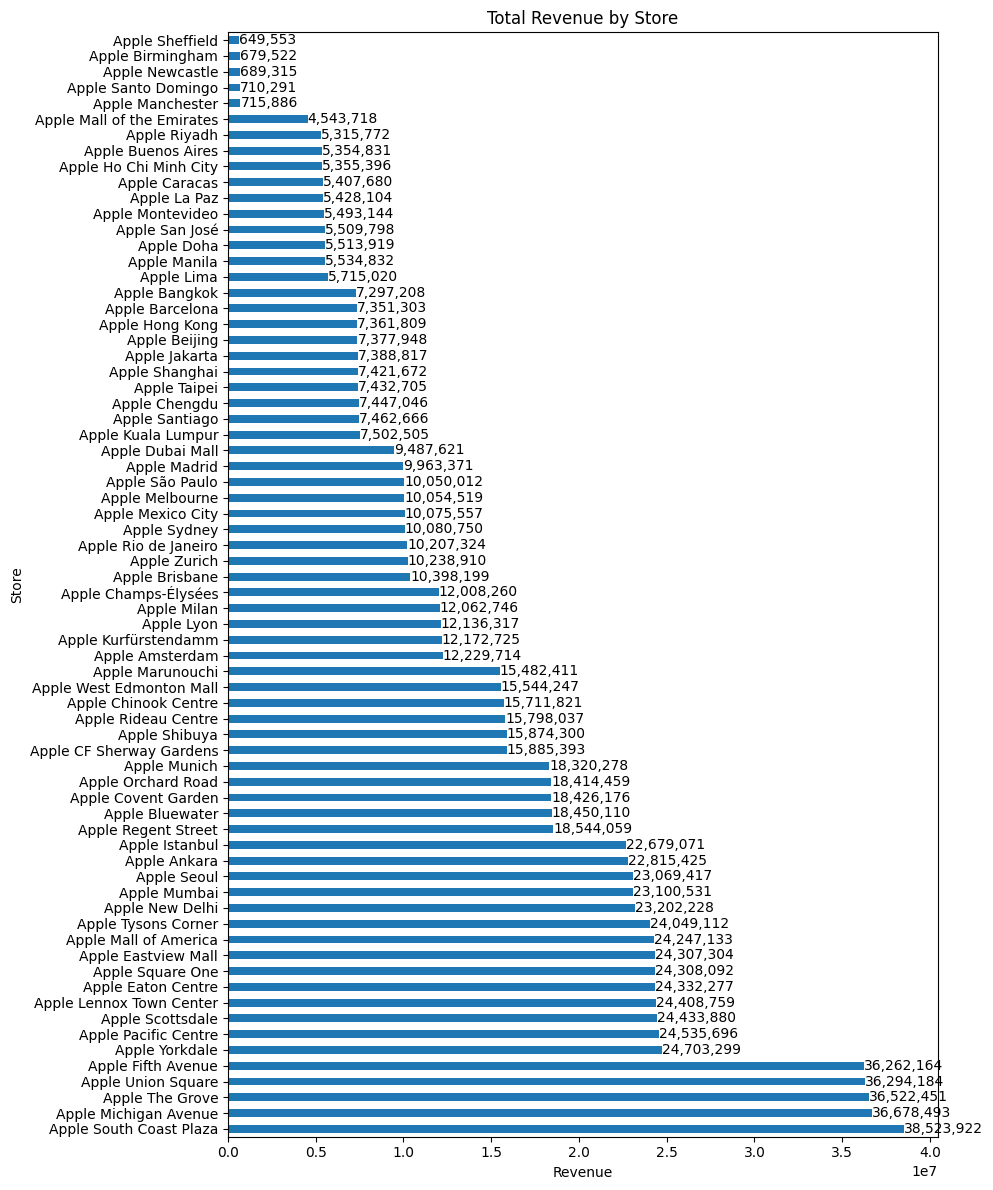

In [47]:
sales_products = sales.merge(
    products,
    on="product_id",
    how="left"
)

sales_products["revenue"] = (
    sales_products["quantity"] * sales_products["price"]
)

sales_store = sales_products.merge(
    stores,
    on="store_id",
    how="left"
)

store_revenue = (
    sales_store
    .groupby("store_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 12))

chart = store_revenue.plot(kind="barh")

plt.title("Total Revenue by Store")
plt.xlabel("Revenue")
plt.ylabel("Store")

for i, value in enumerate(store_revenue):
    chart.text(
        value,
        i,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()  
plt.show()

For five real requests — a revenue trend, a price-spread comparison across categories, a category revenue share, a price-vs-units
relationship, and a warranty claim_status breakdown — choose and justify the correct chart type for each, and explain which one
you would lead with in a CEO meeting

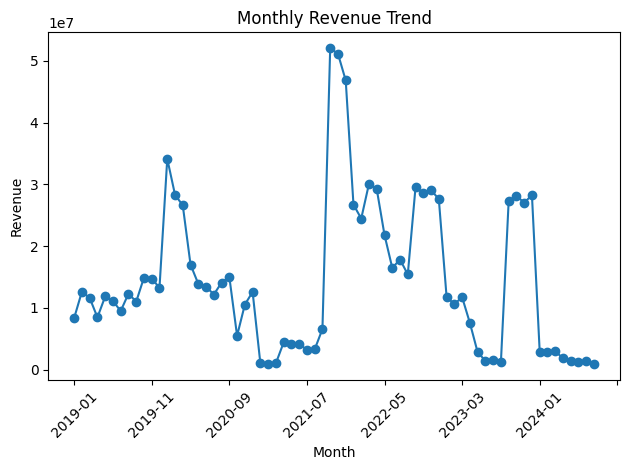

In [49]:
sales_products["sale_date"] = pd.to_datetime(
    sales_products["sale_date"]
)

monthly_revenue = (
    sales_products
    .groupby(sales_products["sale_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

monthly_revenue.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

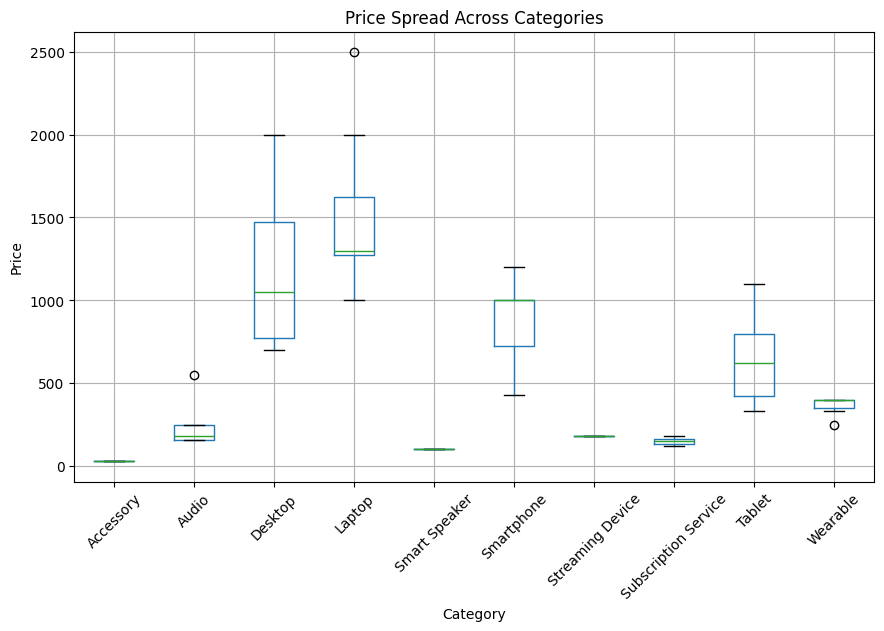

In [50]:
price_spread = (
    products
    .merge(category, on="category_id", how="left")
)

price_spread.boxplot(
    column="price",
    by="category_name",
    figsize=(10, 6)
)

plt.title("Price Spread Across Categories")
plt.xlabel("Category")
plt.ylabel("Price")

plt.suptitle("")
plt.xticks(rotation=45)

plt.show()

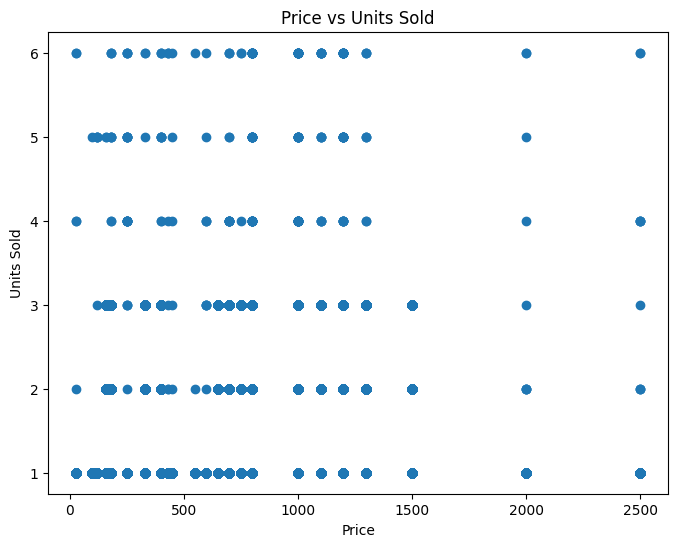

In [55]:
price_units = sales.merge(
    products,
    on="product_id",
    how="left"
)

plt.figure(figsize=(8, 6))

plt.scatter(
    price_units["price"],
    price_units["quantity"]
)

plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")

plt.show()

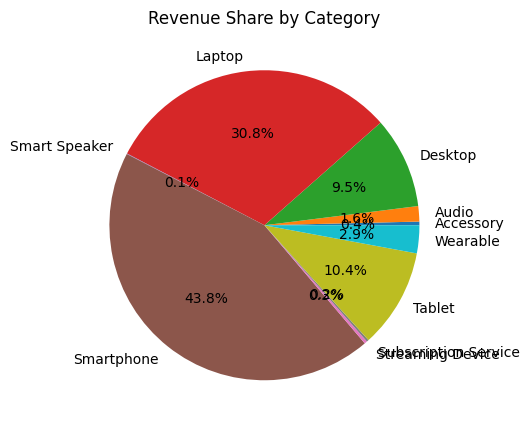

In [64]:
category_revenue = (
    sales_products
    .merge(
        category,
        on="category_id",
        how="left"
    )
    .groupby("category_name")["revenue"]
    .sum()
)

category_revenue.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5, 6)
)

plt.title("Revenue Share by Category")
plt.ylabel("")
grid = True

plt.show()

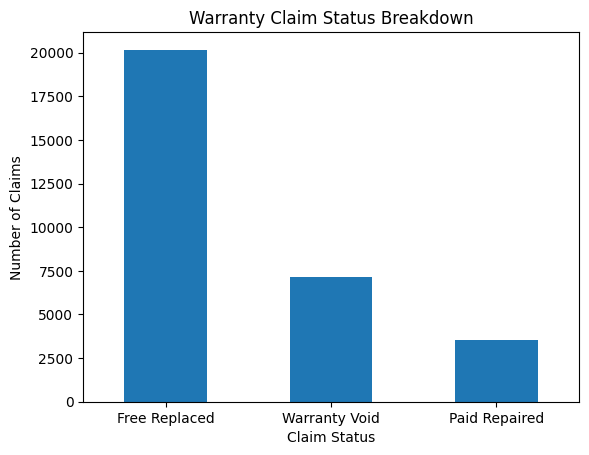

In [65]:
claim_status_count = warranty["claim_status"].value_counts()

claim_status_count.plot(kind="bar")

plt.title("Warranty Claim Status Breakdown")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")

plt.xticks(rotation=0)

plt.show()